# Driving the xnn MDI engine from LAMMPS: liquid-argon NVE and $g(r)$

The companion notebook [`mdi_argon_md.ipynb`](mdi_argon_md.ipynb) served a trained
checkpoint over the [MolSSI Driver Interface](https://github.com/MolSSI-MDI/MDI_Library)
and drove it from a hand-written Python driver, so every protocol command was visible.
This notebook replaces that driver with **LAMMPS**: the production coupling. LAMMPS owns
the integrator, the thermodynamic output and its analysis machinery (here a radial
distribution function), while **every energy, force and stress evaluation happens in the
unchanged xnn engine** via LAMMPS' `fix mdi/qm`.

| stage | tool |
|---|---|
| model | `runs/mdi_argon/best.pt` from the companion notebook (trained here if missing) |
| driver | `lmp` with the MDI package: `fix mdi/qm`, NVE, RDF |
| engine | `xnn mdi --ckpt best.pt` over TCP, byte-for-byte the same command as before |
| validate | LAMMPS step-0 potential energy and pressure vs direct evaluation |

**Requirements.** Besides `xnn[mdi]`, a LAMMPS executable built with the MDI package:

```bash
git clone --depth 1 --branch stable https://github.com/lammps/lammps
cmake -B lammps/build -S lammps/cmake -D PKG_MDI=yes -D BUILD_MPI=no -D CMAKE_BUILD_TYPE=Release
cmake --build lammps/build -j        # -> lammps/build/lmp
```

Put `lmp` on `PATH` (or point the `XNN_LMP` environment variable at it). Unlike the
companion notebook, this one never calls the MDI library in-process (driver and engine
are both subprocesses), so it can be re-run without restarting the kernel.


## 0. Setup


In [1]:
# silence the expected warnings (TorchScript scripting + e3nn torch.load)
import logging, warnings
logging.getLogger("cuequivariance").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning,
                        message="The TorchScript type system doesn't support")
warnings.filterwarnings("ignore", category=FutureWarning,
                        message="You are using `torch.load` with `weights_only=False`")

import os, sys, time, shutil, subprocess
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LMP = (os.environ.get("XNN_LMP") or shutil.which("lmp")
       or str(Path(sys.executable).parent / "lmp"))
assert os.path.exists(LMP), ("LAMMPS with the MDI package not found: build it with "
                             "-D PKG_MDI=yes and put `lmp` on PATH or set XNN_LMP")

import xnn
print("xnn:", xnn.__version__, "| device:", DEVICE, "| lmp:", LMP)

xnn: 0.1.0 | device: cuda | lmp: /D3/sina/xnn/.venv/bin/lmp


## 1. Data and checkpoint

Same bundled `argon_md` hub data and the same 30-epoch MACE checkpoint as the companion
notebook; if `runs/mdi_argon/best.pt` is not there yet, it is trained here with the
identical recipe.


In [2]:
from xnn.common.data import load_dataset

train_structs = load_dataset("argon_md", split="train")
test_structs = load_dataset("argon_md", split="test")
CUTOFF, SPECIES, E0 = 6.0, [18], {18: 0.0}

CKPT = "runs/mdi_argon/best.pt"
if os.path.exists(CKPT):
    print("reusing the checkpoint trained in mdi_argon_md.ipynb")
else:
    from xnn.common.config import from_dict
    from xnn.common.data import AtomicDataset
    from xnn.common.train import Trainer
    probe = AtomicDataset(train_structs[:10], CUTOFF)
    graphs = [probe[i] for i in range(len(probe))]
    lam = float(sum(g.num_edges for g in graphs) / sum(g.num_nodes for g in graphs))
    core = from_dict({
        "model": {"name": "mace", "cutoff": CUTOFF, "n_features": 32,
                  "n_interactions": 2, "n_rbf": 8, "species": SPECIES, "max_ell": 3,
                  "max_L": 1, "correlation": 3, "hidden_irreps": "32x0e+32x1o",
                  "MLP_irreps": "16x0e", "avg_num_neighbors": lam,
                  "atomic_energies": [E0[z] for z in SPECIES]},
        "data": {"batch_size": 10},
        "optim": {"lr": 0.01, "weight_decay": 5e-7, "epochs": 30,
                  "energy_weight": 1.0, "force_weight": 100.0, "scheduler": "plateau"},
        "device": DEVICE, "seed": 0, "output_dir": "runs/mdi_argon",
    })
    rng = np.random.default_rng(0)
    idx = rng.permutation(len(train_structs))
    Trainer(core,
            AtomicDataset([train_structs[i] for i in idx[:180]], CUTOFF),
            AtomicDataset([train_structs[i] for i in idx[180:]], CUTOFF)).fit()
    print(f"trained -> {CKPT}")

reusing the checkpoint trained in mdi_argon_md.ipynb


## 2. LAMMPS inputs

Two files, both generated into `runs/mdi_argon_lammps/`:

**`data.argon`**: the same 400-atom test frame used in the companion notebook, written
in LAMMPS `data` format. The dataset stores unwrapped MD coordinates, so the frame is
wrapped into the box first (`read_data` requires in-box positions; under periodic
boundaries this is the identical system).

**`in.argon`**: a completely ordinary LAMMPS NVE script, except that **no `pair_style`
is defined**. The MDI-specific lines are:

* `fix qm all mdi/qm virial yes elements Ar`: outsources energy/forces to the connected
  MDI engine; `elements Ar` maps LAMMPS atom type 1 to $Z=18$ for the `>ELEMENTS`
  command, `virial yes` also requests `<STRESS` so LAMMPS can report pressure.
* `atom_modify map array`: required by the fix to gather atoms by ID.
* `comm_modify cutoff 10.0`: with no pair style there is no ghost-atom range, so the
  pair-less RDF compute must be given one explicitly.

At startup the fix probes which commands the engine registered (via MDI's
`MDI_Check_command_exists`) and adapts: it skips `>CELL_DISPL` (the engine does not
register it; a rigid cell shift is irrelevant to the graph) and falls back from `<PE`
to `<ENERGY`. Velocities start at $2\times 85$ K for the same
kinetic-potential-repartition reason as in the companion notebook.


In [3]:
from ase import Atoms
import ase.io

RUN = "runs/mdi_argon_lammps"
os.makedirs(RUN, exist_ok=True)

s0 = test_structs[0]
at = Atoms(numbers=s0["atomic_numbers"], positions=s0["pos"], cell=s0["cell"], pbc=True)
at.wrap()
ase.io.write(f"{RUN}/data.argon", at, format="lammps-data", masses=True)

N_STEPS = 240
IN_ARGON = f'''\
# Liquid argon NVE; energy/forces/stress from an xnn model over MDI
units           metal
atom_style      atomic
atom_modify     map array
comm_modify     cutoff 10.0

read_data       data.argon
mass            1 39.948

velocity        all create 170.0 87287 mom yes

timestep        0.005                     # metal units (ps) -> 5 fs

fix             integrate all nve
fix             qm all mdi/qm virial yes elements Ar

compute         grdf all rdf 100 cutoff 8.0
fix             rdf all ave/time 10 24 {N_STEPS} c_grdf[*] file rdf.argon mode vector

thermo_style    custom step time temp pe ke etotal press
thermo_modify   format float %20.13g
thermo          1

run             {N_STEPS}
'''
open(f"{RUN}/in.argon", "w").write(IN_ARGON)
print(IN_ARGON)

# Liquid argon NVE; energy/forces/stress from an xnn model over MDI
units           metal
atom_style      atomic
atom_modify     map array
comm_modify     cutoff 10.0

read_data       data.argon
mass            1 39.948

velocity        all create 170.0 87287 mom yes

timestep        0.005                     # metal units (ps) -> 5 fs

fix             integrate all nve
fix             qm all mdi/qm virial yes elements Ar

compute         grdf all rdf 100 cutoff 8.0
fix             rdf all ave/time 10 24 240 c_grdf[*] file rdf.argon mode vector

thermo_style    custom step time temp pe ke etotal press
thermo_modify   format float %20.13g
thermo          1

run             240



## 3. Run: LAMMPS driver + xnn engine

Exactly the two commands from the companion notebook's closing section, with TCP instead
of MPI so a plain serial `lmp` works: the LAMMPS **driver initializes first** (it owns
the listening socket), then the engine connects. LAMMPS sends `EXIT` to the engine when
it shuts down.


In [4]:
PORT = 8021

lmp_proc = subprocess.Popen(
    [LMP, "-mdi", f"-role DRIVER -name LAMMPS -method TCP -port {PORT}",
     "-in", "in.argon", "-log", "log.argon"],
    cwd=RUN, stdout=open(f"{RUN}/lmp_screen.out", "w"), stderr=subprocess.STDOUT)

engine_proc = subprocess.Popen(
    [sys.executable, "-W", "ignore", "-m", "xnn.common.deploy.mdi_engine",
     "--ckpt", os.path.abspath(CKPT), "--device", DEVICE, "--dtype", "float64",
     "-mdi", f"-role ENGINE -name xnn -method TCP -port {PORT} -hostname localhost"],
    stdout=open(f"{RUN}/engine.log", "w"), stderr=subprocess.STDOUT)

t0 = time.time()
lmp_rc = lmp_proc.wait(timeout=1500)
try:
    eng_rc = engine_proc.wait(timeout=120)
except subprocess.TimeoutExpired:
    engine_proc.kill()
    eng_rc = "killed (driver never connected?)"
print(f"finished in {time.time()-t0:.0f} s | lammps exit {lmp_rc} | engine exit {eng_rc}")
assert lmp_rc == 0 and eng_rc == 0

finished in 83 s | lammps exit 0 | engine exit 0


## 4. Thermodynamics from the LAMMPS log

The thermo table is parsed straight out of `log.argon`; nothing on the analysis side
knows or cares that the forces came from a neural network in another process.


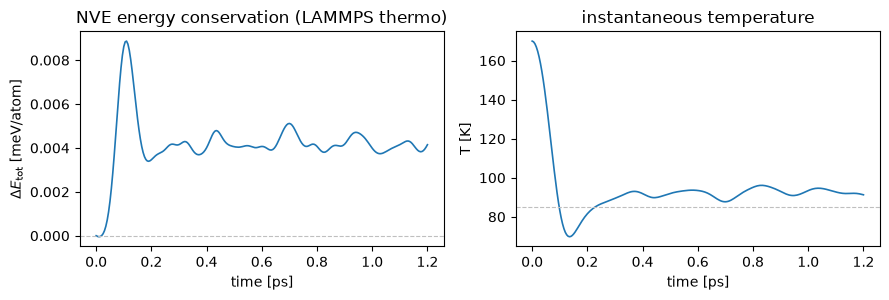

max |E_tot(t) - E_tot(0)| = 0.009 meV/atom over 1.2 ps | <T> (last half) = 92.5 K
Loop time of 76.717 on 1 procs for 240 steps with 400 atoms
Performance: 1.351 ns/day, 17.759 hours/ns, 3.128 timesteps/s, 1.251 katom-step/s


In [5]:
def read_thermo(logfile):
    lines = open(logfile).read().splitlines()
    i0 = next(i for i, l in enumerate(lines) if l.lstrip().startswith("Step"))
    cols = lines[i0].split()
    rows = []
    for l in lines[i0 + 1:]:
        if l.startswith("Loop time"):
            break
        rows.append([float(x) for x in l.split()])
    return cols, np.array(rows)

cols, th = read_thermo(f"{RUN}/log.argon")
t_ps, T, pe, ke, etot, press = (th[:, cols.index(c)] for c in
                                ("Time", "Temp", "PotEng", "KinEng", "TotEng", "Press"))
N = len(at)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.1))
ax[0].plot(t_ps, (etot - etot[0]) / N * 1000, color="#1f77b4", lw=1.2)
ax[0].axhline(0, color="0.75", lw=0.8, ls="--")
ax[0].set_xlabel("time [ps]")
ax[0].set_ylabel("$\\Delta E_\\mathrm{tot}$ [meV/atom]")
ax[0].set_title("NVE energy conservation (LAMMPS thermo)")
ax[1].plot(t_ps, T, color="#1f77b4", lw=1.2)
ax[1].axhline(85, color="0.75", lw=0.8, ls="--")
ax[1].set_xlabel("time [ps]"); ax[1].set_ylabel("T [K]")
ax[1].set_title("instantaneous temperature")
plt.tight_layout(); plt.show()

drift = np.abs(etot - etot[0]).max() / N * 1000
print(f"max |E_tot(t) - E_tot(0)| = {drift:.3f} meV/atom over {t_ps[-1]:.1f} ps | "
      f"<T> (last half) = {T[len(T) // 2:].mean():.1f} K")
for l in open(f"{RUN}/log.argon"):
    if l.startswith(("Loop time", "Performance")):
        print(l.rstrip())

## 5. Validate against direct evaluation

The step-0 state is exactly the wrapped frame we wrote to `data.argon` (`velocity
create` does not move atoms), so LAMMPS' first `PotEng` must equal a direct
`XNNCalculator` evaluation of that frame.

One subtlety, continuing the unit-constant story from the companion notebook: this
coupling chains **three** codes' conversion constants (the engine converts eV
$\rightarrow$ Hartree with CODATA 2018 values; LAMMPS converts Hartree $\rightarrow$ eV
using the MDI library's own CODATA 2014-era factors). The net effect is a uniform scale
factor of about $8\times 10^{-9}$, i.e. agreement at the $10^{-7}$ eV level instead of
the companion's $10^{-14}$: unavoidable between independent codes, physically
irrelevant, and harmless to the dynamics (a conservative potential scaled by a constant
is still conservative).

The pressure decomposition also checks the MDI stress-sign convention end to end:
LAMMPS' reported pressure must equal its own kinetic term plus the virial term from the
engine's `<STRESS`.


In [6]:
torch.set_default_dtype(torch.float64)
from ase import units as u
from xnn.common.models import build_model, ForceStressOutput
from xnn.common.deploy import XNNCalculator

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
model = ForceStressOutput(build_model(ckpt["cfg"].model), compute_stress=True).double()
model.load_state_dict(ckpt["model"])
at.calc = XNNCalculator(model, cutoff=ckpt["cfg"].model.cutoff, device=DEVICE)

e_dir = at.get_potential_energy()
p_virial = -at.get_stress()[:3].mean() / u.bar
p_kin = 2 * ke[0] / (3 * at.get_volume()) / u.bar     # from LAMMPS' own KinEng

print(f"step-0 PotEng: LAMMPS {pe[0]:.10f} eV | direct {e_dir:.10f} eV | "
      f"diff {abs(pe[0] - e_dir):.1e} eV ({abs(pe[0] - e_dir) / abs(e_dir):.1e} relative)")
print(f"step-0 Press : LAMMPS {press[0]:.2f} bar | "
      f"kinetic {p_kin:.2f} + virial {p_virial:.2f} = {p_kin + p_virial:.2f} bar")
assert abs(pe[0] - e_dir) < 1e-5
assert abs(press[0] - (p_kin + p_virial)) < 1.0

step-0 PotEng: LAMMPS -28.7660983948 eV | direct -28.7660986307 eV | diff 2.4e-07 eV (8.2e-09 relative)
step-0 Press : LAMMPS 793.33 bar | kinetic 606.37 + virial 186.96 = 793.33 bar


## 6. A driver-side observable: the Ar-Ar radial distribution function

The RDF was accumulated by **LAMMPS itself** (`compute rdf` + `fix ave/time`, averaged
over the run) while the potential lived in the engine: the point of MDI coupling is that
the driver's whole ecosystem keeps working. The curve shows the classic liquid-argon
structure: first coordination shell near 3.6 A, damped oscillations toward
$g(r) \rightarrow 1$.


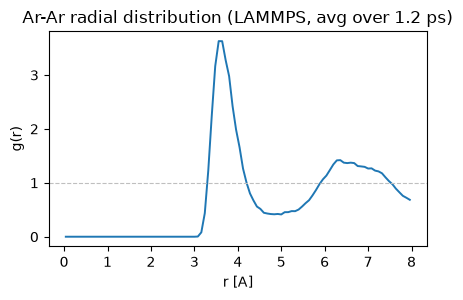

first peak: r = 3.56 A, g = 3.63


In [7]:
rdf = np.loadtxt(f"{RUN}/rdf.argon", skiprows=4)
r, g = rdf[:, 1], rdf[:, 2]

fig, ax = plt.subplots(figsize=(4.6, 3.1))
ax.plot(r, g, color="#1f77b4", lw=1.4)
ax.axhline(1, color="0.75", lw=0.8, ls="--")
ax.set_xlabel("r [A]"); ax.set_ylabel("g(r)")
ax.set_title("Ar-Ar radial distribution (LAMMPS, avg over 1.2 ps)")
plt.tight_layout(); plt.show()
print(f"first peak: r = {r[np.argmax(g)]:.2f} A, g = {g.max():.2f}")

## 7. What the engine saw


In [8]:
print("--- runs/mdi_argon_lammps/engine.log (tail) ---")
print("\n".join(open(f"{RUN}/engine.log").read().splitlines()[-5:]))

--- runs/mdi_argon_lammps/engine.log (tail) ---
INFO:__main__:MDI connection established
INFO:__main__:received 400 atoms, elements [18]
INFO:__main__:step 100: avg 150.1 ms/step
INFO:__main__:step 200: avg 108.9 ms/step
INFO:__main__:engine finished: 241 calculations, avg 102.1 ms/step


## Where to go from here

**Production launch.** TCP was convenient for a notebook; on a cluster run both codes
under one `mpirun` with the MPI method (`mpi4py` required on the engine side):

```bash
mpirun -np 1 xnn mdi --ckpt runs/mdi_argon/best.pt --device cuda:0 --dtype float64 \
        -mdi "-role ENGINE -name xnn -method MPI" \
    : -np 4 lmp -mdi "-role DRIVER -name LAMMPS -method MPI" -in in.argon
```

**Anything LAMMPS can drive, the engine can serve.** Swap `fix nve` for NPT, add more
fixes/computes, or use `fix mdi/qm` in hybrid QM/MM-style setups; on the xnn side,
point `--ckpt` at any family's `best.pt` (NequIP, Allegro, CACE, SchNet, ANI, PhysNet,
BAMBOO, with or without LES). The protocol details of what travels over the wire are in
the companion notebook [`mdi_argon_md.ipynb`](mdi_argon_md.ipynb).
